In [43]:
import warnings

warnings.filterwarnings("ignore")

In [44]:
# import os
# import shutil
# import pandas as pd

# # Paths
# train_csv = 'image_features_train.csv'
# test_csv = 'image_features_test.csv'
# source_dir = 'Static_Features'
# output_dir = 'dataset_Split'

# # Read CSVs
# df_train = pd.read_csv(train_csv)
# df_test = pd.read_csv(test_csv)

# # Function to copy files to train/test folders
# def organize_dataset(df, split):
#     for _, row in df.iterrows():
#         label = row['Label']
#         image_name = row['ImageName'].replace('.png', '.json')  # convert to json
#         src_path = os.path.join(source_dir, label, image_name)
#         dst_dir = os.path.join(output_dir, split, label)
#         dst_path = os.path.join(dst_dir, image_name)

#         os.makedirs(dst_dir, exist_ok=True)

#         if os.path.exists(src_path):
#             shutil.copy(src_path, dst_path)
#         else:
#             print(f"[WARNING] File not found: {src_path}")

# # Organize both datasets
# organize_dataset(df_train, 'train')
# organize_dataset(df_test, 'test')

# print("Dataset organization complete.")


In [45]:
import os
import json
import torch
from torch_geometric.data import Data

# Define the root directory where JSON files are stored, organized by family subdirectories
root_dir = "Static_Features"  # adjust this path to your dataset

# Define root directories
train_dir = "dataset_Split/train"  # Path to the training data folder containing JSON files
test_dir = "dataset_Split/test"  # Path to the test data folder containing JSON files

# Step 1: Gather all unique features across the dataset for consistent one-hot encoding
all_features = set()
families = []  # list to hold family names (labels)
file_paths = []  # list to hold file paths corresponding to each sample
labels = []     # list to hold label (family) for each sample

for family in os.listdir(root_dir):
    fam_path = os.path.join(root_dir, family)
    if not os.path.isdir(fam_path):
        continue
    families.append(family)
    for file in os.listdir(fam_path):
        if file.endswith(".json"):
            file_paths.append(os.path.join(fam_path, file))
            labels.append(family)
            # Read the JSON to collect features
            with open(os.path.join(fam_path, file), 'r') as f:
                try:
                    app_json = json.load(f)
                except json.JSONDecodeError:
                    continue  # skip corrupted JSON
            # Extract features: permissions and components (activities, services, receivers, providers if any)
            perms = app_json.get("permissions", [])
            acts = app_json.get("activities", [])
            servs = app_json.get("services", [])
            recvs = app_json.get("receivers", [])
            provs = app_json.get("providers", [])  # if providers key exists
            # Use distinctive prefixes to avoid name collisions between categories
            perms = [f"perm::{p}" for p in perms]
            acts = [f"act::{a}" for a in acts]
            servs = [f"serv::{s}" for s in servs]
            recvs = [f"recv::{r}" for r in recvs]
            provs = [f"prov::{p}" for p in provs]
            features = perms + acts + servs + recvs + provs
            for feat in features:
                all_features.add(feat)

# Create a mapping from feature name to index for one-hot encoding
all_features = sorted(list(all_features))
feature_index = {feat: idx for idx, feat in enumerate(all_features)}
num_features = len(feature_index)
print(f"Total unique features (nodes) in dataset: {num_features}")

# Step 2: Build graph Data objects for each app
label_to_index = {fam: i for i, fam in enumerate(sorted(set(labels)))}  # map family name to class index
train_graph_data_list = []
for path, family in zip(file_paths, labels):
    with open(path, 'r') as f:
        try:
            app_json = json.load(f)
        except json.JSONDecodeError:
            continue  # skip if not readable
    perms = app_json.get("permissions", [])
    acts = app_json.get("activities", [])
    servs = app_json.get("services", [])
    recvs = app_json.get("receivers", [])
    provs = app_json.get("providers", [])
    perms = [f"perm::{p}" for p in perms]
    acts = [f"act::{a}" for a in acts]
    servs = [f"serv::{s}" for s in servs]
    recvs = [f"recv::{r}" for r in recvs]
    provs = [f"prov::{p}" for p in provs]
    features = list(set(perms + acts + servs + recvs + provs))  # unique nodes in this app

    if len(features) == 0:
        continue

    # Create node feature matrix (one-hot vectors)
    node_indices = [feature_index[feat] for feat in features]
    num_nodes = len(node_indices)
    # Initialize feature matrix for this graph: shape [num_nodes, num_features]
    x = torch.zeros((num_nodes, num_features), dtype=torch.float)
    for i, feat_idx in enumerate(node_indices):
        x[i, feat_idx] = 1.0

    # Create edges: fully connect all nodes (undirected graph)
    if num_nodes == 1:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    else:
        edges = []
        for i in range(num_nodes):
            for j in range(i+1, num_nodes):
                edges.append([i, j])
                edges.append([j, i])
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    # Graph label
    label_idx = label_to_index[family]
    y = torch.tensor([label_idx], dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.filenames = [os.path.basename(path)] 
    train_graph_data_list.append(data)

# Step 3: Read test data (similar to training data processing)
test_graph_data_list = []
test_file_paths = []  # list to hold file paths for test set
test_labels = []      # list to hold labels for test set

for family in os.listdir(test_dir):
    fam_path = os.path.join(test_dir, family)
    if not os.path.isdir(fam_path):
        continue
    for file in os.listdir(fam_path):
        if file.endswith(".json"):
            test_file_paths.append(os.path.join(fam_path, file))
            test_labels.append(family)
            with open(os.path.join(fam_path, file), 'r') as f:
                try:
                    app_json = json.load(f)
                except json.JSONDecodeError:
                    continue
            perms = app_json.get("permissions", [])
            acts = app_json.get("activities", [])
            servs = app_json.get("services", [])
            recvs = app_json.get("receivers", [])
            provs = app_json.get("providers", [])
            perms = [f"perm::{p}" for p in perms]
            acts = [f"act::{a}" for a in acts]
            servs = [f"serv::{s}" for s in servs]
            recvs = [f"recv::{r}" for r in recvs]
            provs = [f"prov::{p}" for p in provs]
            features = list(set(perms + acts + servs + recvs + provs))

            if len(features) == 0:
                continue

            node_indices = [feature_index[feat] for feat in features]
            num_nodes = len(node_indices)
            x = torch.zeros((num_nodes, num_features), dtype=torch.float)
            for i, feat_idx in enumerate(node_indices):
                x[i, feat_idx] = 1.0

            if num_nodes == 1:
                edge_index = torch.zeros((2, 0), dtype=torch.long)
            else:
                edges = []
                for i in range(num_nodes):
                    for j in range(i+1, num_nodes):
                        edges.append([i, j])
                        edges.append([j, i])
                edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

            label_idx = label_to_index[family]
            y = torch.tensor([label_idx], dtype=torch.long)

            data = Data(x=x, edge_index=edge_index, y=y)
            data.filenames = [os.path.basename(path)] 
            test_graph_data_list.append(data)

print(f"Total training graphs: {len(train_graph_data_list)}, Total test graphs: {len(test_graph_data_list)}")


Total unique features (nodes) in dataset: 4232
Total training graphs: 1427, Total test graphs: 433


In [46]:
import numpy as np
from sklearn.model_selection import train_test_split

# Prepare arrays of labels for splitting
all_labels = np.concatenate((
    np.array([data.y.item() if hasattr(data.y, 'item') else data.y for data in train_graph_data_list]),
    np.array([data.y.item() if hasattr(data.y, 'item') else data.y for data in test_graph_data_list])
))
num_classes = len(set(all_labels))


# Compute class weights from training data (to handle class imbalance)
train_labels = np.array([data.y.item() for data in train_graph_data_list])
class_counts = np.bincount(train_labels, minlength=num_classes)
total_train = len(train_labels)
# Inverse frequency weighting: weight_c = total_samples / (num_classes * count_c)
class_weights = {c: total_train/(num_classes * count) if count > 0 else 0.0 
                 for c, count in enumerate(class_counts)}
# Create a weight tensor in the order of class indices
weights_tensor = torch.tensor([class_weights[i] for i in range(num_classes)], dtype=torch.float)
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.5058489897199575), 1: np.float64(18.294871794871796), 2: np.float64(0.30834053586862575), 3: np.float64(0.6345042240995998), 4: np.float64(6.098290598290598), 5: np.float64(0.5572042171026943), 6: np.float64(1.4635897435897436), 7: np.float64(1.2914027149321268), 8: np.float64(4.065527065527066), 9: np.float64(2.4947552447552446), 10: np.float64(1.1554655870445345), 11: np.float64(1.6631701631701632), 12: np.float64(1.6142533936651584)}


In [47]:
from torch_geometric.loader import DataLoader

batch_size = 32
train_loader = DataLoader(train_graph_data_list, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_graph_data_list, batch_size=batch_size, shuffle=False)


In [48]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm as GraphBatchNorm

class GCNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super(GCNClassifier, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = GraphBatchNorm(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = GraphBatchNorm(hidden_channels)
        self.dropout = nn.Dropout(0.5)
        self.lin = nn.Linear(hidden_channels, num_classes)
    
    def forward(self, x, edge_index, batch):
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = nn.functional.relu(x)
        x = self.dropout(x)
        # Second GCN layer
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = nn.functional.relu(x)

        features = x
        # Global mean pooling to get graph-level representation
        x = global_mean_pool(x, batch)  # pool over nodes in each graph
        # Final linear layer for classification
        out = self.lin(x)
        return out, features


In [49]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

# Initialize model, loss criterion, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCNClassifier(in_channels=num_features, hidden_channels=64, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
best_val_acc = 0.0
best_model_state = None

for epoch in range(1, num_epochs+1):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch.to(device)
        optimizer.zero_grad()
        out, _ = model(batch.x, batch.edge_index, batch.batch)  # forward pass
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)
    
    # Validation evaluation
    model.eval()
    all_val_preds = []
    all_val_labels = []
    val_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            batch.to(device)
            out, _ = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            val_loss += loss.item()
            preds = out.argmax(dim=1).cpu().numpy()
            labels = batch.y.cpu().numpy()
            all_val_preds.extend(preds)
            all_val_labels.extend(labels)
    val_loss /= len(test_loader)
    val_acc = accuracy_score(all_val_labels, all_val_preds)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.cpu() for k,v in model.state_dict().items()}  # save best model weights
    print(f"Epoch {epoch:02d}: Train Loss = {avg_train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")


Epoch 01: Train Loss = 1.5804, Val Loss = 2.4063, Val Acc = 0.1778
Epoch 02: Train Loss = 0.6660, Val Loss = 0.8523, Val Acc = 0.9746
Epoch 03: Train Loss = 0.3269, Val Loss = 0.1933, Val Acc = 0.9954
Epoch 04: Train Loss = 0.1804, Val Loss = 0.1093, Val Acc = 0.9954
Epoch 05: Train Loss = 0.0981, Val Loss = 0.0569, Val Acc = 0.9977
Epoch 06: Train Loss = 0.0663, Val Loss = 0.0412, Val Acc = 0.9977
Epoch 07: Train Loss = 0.0540, Val Loss = 0.0323, Val Acc = 0.9977
Epoch 08: Train Loss = 0.0365, Val Loss = 0.0237, Val Acc = 0.9977
Epoch 09: Train Loss = 0.0283, Val Loss = 0.0175, Val Acc = 0.9977
Epoch 10: Train Loss = 0.0222, Val Loss = 0.0160, Val Acc = 0.9977


In [50]:
from sklearn.metrics import f1_score, classification_report

# Load best model weights before evaluation (if we saved any)
if best_model_state is not None:
    model.load_state_dict(best_model_state)

model.eval()
all_test_preds = []
all_test_labels = []
with torch.no_grad():
    for batch in test_loader:
        batch.to(device)
        out, _ = model(batch.x, batch.edge_index, batch.batch)
        preds = out.argmax(dim=1).cpu().numpy()
        labels = batch.y.cpu().numpy()
        all_test_preds.extend(preds)
        all_test_labels.extend(labels)

# Compute accuracy and macro-F1
test_acc = accuracy_score(all_test_labels, all_test_preds)
test_macro_f1 = f1_score(all_test_labels, all_test_preds, average='macro')
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}")

# Map integer labels back to family names using label_to_index
index_to_label = {v: k for k, v in label_to_index.items()}

# Convert integer labels back to family names for both test labels and predictions
test_labels_named = [index_to_label[label] for label in all_test_labels]
test_preds_named = [index_to_label[pred] for pred in all_test_preds]

# Optional: detailed classification report per class
print("\nClassification Report:")
print(classification_report(test_labels_named, test_preds_named, digits=4))


Test Accuracy: 0.9977
Test Macro-F1: 0.9989

Classification Report:
               precision    recall  f1-score   support

  Anserverbot     1.0000    1.0000    1.0000        64
      Bmaster     1.0000    1.0000    1.0000         2
   DroidDream     0.9907    1.0000    0.9953       107
      Geinimi     1.0000    0.9808    0.9903        52
      MisoSMS     1.0000    1.0000    1.0000         9
     Nickyspy     1.0000    1.0000    1.0000        59
NotCompatible     1.0000    1.0000    1.0000        22
       Pletor     1.0000    1.0000    1.0000        26
    Rootsmart     1.0000    1.0000    1.0000         8
     Sandroid     1.0000    1.0000    1.0000        13
     TigerBot     1.0000    1.0000    1.0000        28
        Wroba     1.0000    1.0000    1.0000        23
        Zitmo     1.0000    1.0000    1.0000        20

     accuracy                         0.9977       433
    macro avg     0.9993    0.9985    0.9989       433
 weighted avg     0.9977    0.9977    0.9977      

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def plot_conf_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()

def plot_metrics(losses, accuracies):
    plt.figure()
    plt.plot(losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.savefig("training_loss.png")
    plt.show()

    plt.figure()
    plt.plot(accuracies, label='Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy Over Epochs')
    plt.legend()
    plt.savefig("training_accuracy.png")
    plt.show()

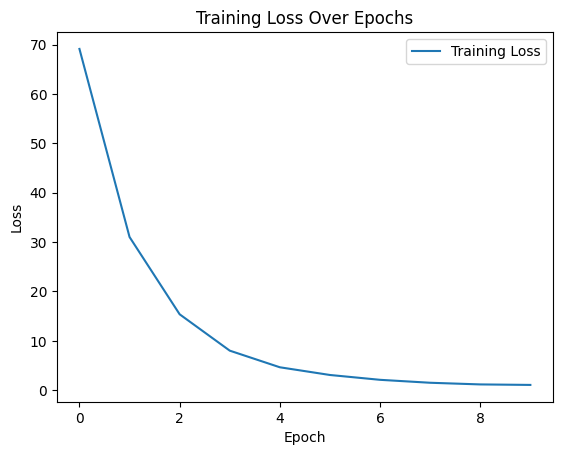

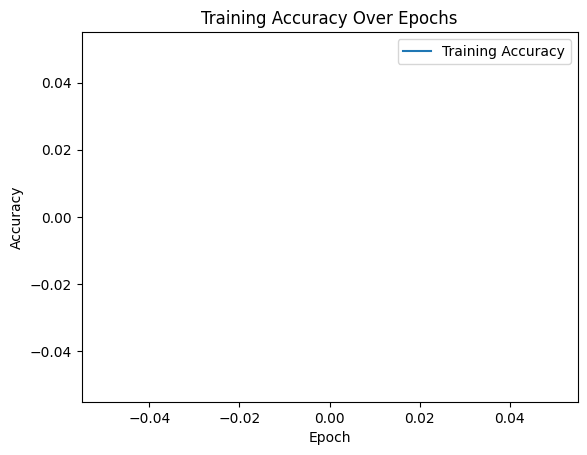

In [52]:
# plot_conf_matrix(all_test_labels, all_test_preds, class_names=test_labels_named)
plot_metrics(training_losses, training_accuracies)

In [63]:
import pandas as pd

# Step 1: Define a function to calculate the maximum feature length across both train and test data
def get_max_feature_size(model, data_dirs, feature_index):
    max_features = 0
    # Loop over both train and test directories
    for data_dir in data_dirs:
        for family in os.listdir(data_dir):
            fam_path = os.path.join(data_dir, family)
            if not os.path.isdir(fam_path):
                continue
            
            # Loop over each JSON file in the family folder
            for file in os.listdir(fam_path):
                if file.endswith(".json"):
                    file_path = os.path.join(fam_path, file)

                    # Step 2: Process the JSON file to create the graph
                    with open(file_path, 'r') as f:
                        try:
                            app_json = json.load(f)
                        except json.JSONDecodeError:
                            continue  # skip corrupted JSON

                    # Extract features from the JSON file
                    perms = app_json.get("permissions", [])
                    acts = app_json.get("activities", [])
                    servs = app_json.get("services", [])
                    recvs = app_json.get("receivers", [])
                    provs = app_json.get("providers", [])
                    perms = [f"perm::{p}" for p in perms]
                    acts = [f"act::{a}" for a in acts]
                    servs = [f"serv::{s}" for s in servs]
                    recvs = [f"recv::{r}" for r in recvs]
                    provs = [f"prov::{p}" for p in provs]
                    features = perms + acts + servs + recvs + provs
                    features = list(set(features))  # Ensure no duplicate features

                    # Step 3: Skip this file if it has no valid features
                    if len(features) == 0:
                        continue

                    # Step 4: Create the feature matrix for this app
                    node_indices = [feature_index[feat] for feat in features]
                    num_nodes = len(node_indices)
                    x = torch.zeros((num_nodes, len(feature_index)), dtype=torch.float)
                    for i, feat_idx in enumerate(node_indices):
                        x[i, feat_idx] = 1.0

                    # Create edges: fully connect all nodes (undirected graph)
                    if num_nodes == 1:
                        edge_index = torch.zeros((2, 0), dtype=torch.long)
                    else:
                        edges = []
                        for i in range(num_nodes):
                            for j in range(i+1, num_nodes):
                                edges.append([i, j])
                                edges.append([j, i])
                        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

                    # Step 5: Skip this file if there are no edges (empty graph)
                    if edge_index.size(1) == 0:
                        continue

                    # Step 6: Predict the label using the model
                    with torch.no_grad():
                        batch = Data(x=x, edge_index=edge_index, batch=torch.zeros(x.size(0), dtype=torch.long))
                        out, features = model(batch.x.to(device), batch.edge_index.to(device), batch.batch.to(device))

                    # Step 7: Set max_features dynamically based on the largest graph size (either train or test)
                    current_feature_size = features.flatten().cpu().numpy().shape[0]
                    if current_feature_size > max_features:
                        max_features = current_feature_size

    return max_features

# Step 8: Define a function to predict for each app and save the features to separate CSV files for train and test
def predict_and_save(model, data_dir, feature_index, max_features, output_csv="predictions_with_features.csv"):
    model.eval()  # Set the model to evaluation mode
    predictions = []  # List to hold the results

    # Loop over the family folders in the data directory (train or test)
    for family in os.listdir(data_dir):
        fam_path = os.path.join(data_dir, family)
        if not os.path.isdir(fam_path):
            continue

        # Loop over each JSON file in the family folder
        for file in os.listdir(fam_path):
            if file.endswith(".json"):
                file_path = os.path.join(fam_path, file)

                # Step 9: Process the JSON file to create the graph
                with open(file_path, 'r') as f:
                    try:
                        app_json = json.load(f)
                    except json.JSONDecodeError:
                        continue  # skip corrupted JSON

                # Extract features from the JSON file
                perms = app_json.get("permissions", [])
                acts = app_json.get("activities", [])
                servs = app_json.get("services", [])
                recvs = app_json.get("receivers", [])
                provs = app_json.get("providers", [])
                perms = [f"perm::{p}" for p in perms]
                acts = [f"act::{a}" for a in acts]
                servs = [f"serv::{s}" for s in servs]
                recvs = [f"recv::{r}" for r in recvs]
                provs = [f"prov::{p}" for p in provs]
                features = perms + acts + servs + recvs + provs
                features = list(set(features))  # Ensure no duplicate features

                # Step 10: Skip this file if it has no valid features
                if len(features) == 0:
                    continue

                # Step 11: Create the feature matrix for this app
                node_indices = [feature_index[feat] for feat in features]
                num_nodes = len(node_indices)
                x = torch.zeros((num_nodes, len(feature_index)), dtype=torch.float)
                for i, feat_idx in enumerate(node_indices):
                    x[i, feat_idx] = 1.0

                # Create edges: fully connect all nodes (undirected graph)
                if num_nodes == 1:
                    edge_index = torch.zeros((2, 0), dtype=torch.long)
                else:
                    edges = []
                    for i in range(num_nodes):
                        for j in range(i+1, num_nodes):
                            edges.append([i, j])
                            edges.append([j, i])
                    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

                # Step 12: Skip this file if there are no edges (empty graph)
                if edge_index.size(1) == 0:
                    continue

                # Step 13: Predict the label using the model
                with torch.no_grad():
                    batch = Data(x=x, edge_index=edge_index, batch=torch.zeros(x.size(0), dtype=torch.long))
                    out, features = model(batch.x.to(device), batch.edge_index.to(device), batch.batch.to(device))

                # Step 14: Flatten the features and ensure consistent length
                flattened_features = features.flatten().cpu().numpy()  # Flatten the feature matrix (node-level embeddings)

                # Pad with zeros if features length is less than max_features
                if len(flattened_features) < max_features:
                    padded_features = list(flattened_features) + [0] * (max_features - len(flattened_features))
                else:
                    padded_features = list(flattened_features[:max_features])  # Trim to max_features if needed

                # Replace any empty values with 0
                feature_list = [0 if f is None else f for f in padded_features]  # Replace None/empty values with 0

                image_name = f"{file.replace('.json', '.png')}"  # Corrected image name
                predictions.append({
                    "ImageName": image_name,
                    "Label": family,  # Use the true label (which is the folder name)
                    **{f"gnn_feature_{i+1}": feature_list[i] for i in range(len(feature_list))}
                })
    
    # Step 15: Save the predictions with features as a CSV file
    df = pd.DataFrame(predictions)
    df.to_csv(output_csv, index=False)
    print(f"Predictions and features saved to {output_csv}")


# Load the trained model (make sure the best model is loaded if you have it saved)
model.load_state_dict(best_model_state)  # If you have saved the best model weights
model.to(device)

# Step 16: Get the max feature size from both train and test datasets
max_features = get_max_feature_size(model, [train_dir, test_dir], feature_index)

# Step 17: Call the prediction function for training data
predict_and_save(model, train_dir, feature_index, max_features, output_csv="gnn_features_train.csv")

# Step 18: Call the prediction function for testing data
predict_and_save(model, test_dir, feature_index, max_features, output_csv="gnn_features_test.csv")

Predictions and features saved to gnn_features_train.csv
Predictions and features saved to gnn_features_test.csv


In [64]:
import pandas as pd

# Read both CSV files
df1 = pd.read_csv('image_features_train.csv')
df2 = pd.read_csv('gnn_features_train.csv')

# Get the names of the first two columns
key_columns = df1.columns[:2].tolist()

# Merge the DataFrames on the first two columns
train_merged_df = pd.merge(df1, df2, on=key_columns, how='inner', suffixes=('_file1', '_file2'))

# Save the merged result to a new CSV
train_merged_df.to_csv('combined_features_train.csv', index=False)

In [65]:
train_merged_df.columns

Index(['ImageName', 'Label', 'mobilenetv2_feature_1', 'mobilenetv2_feature_2',
       'mobilenetv2_feature_3', 'mobilenetv2_feature_4',
       'mobilenetv2_feature_5', 'mobilenetv2_feature_6',
       'mobilenetv2_feature_7', 'mobilenetv2_feature_8',
       ...
       'gnn_feature_16951', 'gnn_feature_16952', 'gnn_feature_16953',
       'gnn_feature_16954', 'gnn_feature_16955', 'gnn_feature_16956',
       'gnn_feature_16957', 'gnn_feature_16958', 'gnn_feature_16959',
       'gnn_feature_16960'],
      dtype='object', length=80962)

In [66]:
import pandas as pd

# Read both CSV files
df1 = pd.read_csv('image_features_test.csv')
df2 = pd.read_csv('gnn_features_test.csv')

# Get the names of the first two columns
key_columns = df1.columns[:2].tolist()

# Merge the DataFrames on the first two columns
test_merged_df = pd.merge(df1, df2, on=key_columns, how='inner', suffixes=('_file1', '_file2'))

# Save the merged result to a new CSV
test_merged_df.to_csv('combined_features_test.csv', index=False)

In [67]:
test_merged_df.columns

Index(['ImageName', 'Label', 'mobilenetv2_feature_1', 'mobilenetv2_feature_2',
       'mobilenetv2_feature_3', 'mobilenetv2_feature_4',
       'mobilenetv2_feature_5', 'mobilenetv2_feature_6',
       'mobilenetv2_feature_7', 'mobilenetv2_feature_8',
       ...
       'gnn_feature_16951', 'gnn_feature_16952', 'gnn_feature_16953',
       'gnn_feature_16954', 'gnn_feature_16955', 'gnn_feature_16956',
       'gnn_feature_16957', 'gnn_feature_16958', 'gnn_feature_16959',
       'gnn_feature_16960'],
      dtype='object', length=80962)